# Training and Evaluation — NSL-KDD

This notebook trains several machine learning models on the processed NSL-KDD dataset.

We compare:

- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- KNN
- MLP Neural Network

The goal is to find the best model for binary intrusion detection:

- `0` = normal traffic
- `1` = attack traffic

The best model is selected using the F1-score.

In [38]:
from pathlib import Path
import time
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

pd.set_option("display.max_columns", 200)

## 1. Load processed datasets

We load the processed files generated by `preprocessing.ipynb`.

These files are already encoded and scaled, so we do not need to preprocess them again.

In [39]:
PROJECT_ROOT = Path(".").resolve()
OUTPUT_DIR = PROJECT_ROOT / "outputs"

X_train = pd.read_csv(OUTPUT_DIR / "X_train_processed.csv")
X_test = pd.read_csv(OUTPUT_DIR / "X_test_processed.csv")

y_train = pd.read_csv(OUTPUT_DIR / "y_train.csv").squeeze()
y_test = pd.read_csv(OUTPUT_DIR / "y_test.csv").squeeze()

feature_names = pd.read_csv(OUTPUT_DIR / "feature_names.csv")["feature"].tolist()

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

display(X_train.head())

X_train shape: (25192, 40)
X_test shape : (22544, 40)
y_train shape: (25192,)
y_test shape : (22544,)


,duration,src_bytes,dst_bytes,logged_in,num_shells,count,srv_count,serror_rate,srv_serror_rate,rerror_rate,srv_rerror_rate,same_srv_rate,diff_srv_rate,srv_diff_host_rate,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,protocol_type_icmp,protocol_type_udp,service_domain_u,service_eco_i,service_ecr_i,service_http,service_private,service_smtp,service_sql_net,service_uucp,service_whois,flag_REJ,flag_RSTO,flag_RSTR,flag_S0,flag_SF
0,-0.113551,-0.009889,-0.039310,-0.807626,-0.018905,-0.720244,-0.354628,-0.640142,-0.633978,-0.372186,-0.373098,0.772109,-0.349282,-0.373886,-0.328634,-0.813985,-0.779157,-0.280673,0.073120,-0.287993,-0.641804,-0.627365,-0.221668,-0.374281,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,-0.113551,-0.010032,-0.039310,-0.807626,-0.018905,-0.624317,-0.368427,-0.640142,-0.633978,-0.372186,-0.373098,-1.320567,0.490836,-0.373886,0.732059,-1.030895,-1.157831,2.764403,2.375620,-0.287993,-0.641804,-0.627365,-0.385140,-0.374281,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.113551,-0.010093,-0.039310,-0.807626,-0.018905,0.334947,-0.299430,1.595477,1.600209,-0.372186,-0.373098,-1.388806,0.042773,-0.373886,0.732059,-0.804947,-0.935081,-0.173828,-0.478183,-0.287993,1.603834,1.614454,-0.385140,-0.374281,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,-0.113551,-0.009996,0.052473,1.238197,-0.018905,-0.694082,-0.313230,-0.193018,-0.187141,-0.372186,-0.373098,0.772109,-0.349282,-0.373886,-1.540854,1.264742,1.069663,-0.440940,-0.380894,0.073759,-0.574435,-0.604947,-0.385140,-0.342768,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.113551,-0.010010,-0.034582,1.238197,-0.018905,-0.476067,0.059355,-0.640142,-0.633978,-0.372186,-0.373098,0.772109,-0.349282,-0.023115,0.732059,1.264742,1.069663,-0.440940,-0.478183,-0.287993,-0.641804,-0.627365,-0.385140,-0.374281,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 2. Helper functions

We define reusable functions to:

- evaluate model predictions,
- display confusion matrices,
- get prediction scores for ROC and Precision-Recall curves,
- plot feature importance for tree-based models.

In [40]:
def evaluate_predictions(y_true, y_pred):
    """
    Calculate the main classification metrics.
    For intrusion detection, F1-score is important because it balances precision and recall.
    """
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0)
    }


def plot_confusion(y_true, y_pred, title):
    """
    Display a confusion matrix.
    Class 0 = normal
    Class 1 = attack
    """
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["normal", "attack"]
    )
    
    disp.plot(values_format="d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def get_score(model, X):
    """
    Return prediction scores needed for ROC and Precision-Recall curves.
    Some models have predict_proba().
    Other models have decision_function().
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, 1]
    
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    
    return None


def plot_feature_importance(model, model_name, top_n=20):
    """
    Plot the most important features for tree-based models.
    """
    importances = model.feature_importances_
    
    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)
    
    display(importance_df.head(top_n))
    
    plt.figure(figsize=(10, 7))
    plt.barh(
        importance_df.head(top_n)["Feature"][::-1],
        importance_df.head(top_n)["Importance"][::-1]
    )
    plt.title(f"Top {top_n} Feature Importances — {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    
    return importance_df

## 3. Define models

We define all machine learning models studied in the course.

Some models are simple baselines, such as Logistic Regression.  
Others are more powerful non-linear methods, such as Random Forest, Extra Trees, and MLP.## 6. Best model selection and interpretation
We choose the best model using F1-score because this is an imbalanced classification problem. Tree-based models are also interpreted using feature importance, and the MLP convergence is visualized with its loss curve.

In [41]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "KNN": KNeighborsClassifier(),

    "MLP Neural Network": MLPClassifier(
        max_iter=500,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=20
    )
}

## 4. Hyperparameter search spaces

We define small hyperparameter grids.

To keep runtime reasonable:

- `GridSearchCV` is used for lighter models,
- `RandomizedSearchCV` is used for heavier models.

In [42]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100]
    },

    "Decision Tree": {
        "max_depth": [5, 10, 15, 20, 30, None],
        "min_samples_split": [2, 5, 10, 20],
        "min_samples_leaf": [1, 2, 4, 8],
        "criterion": ["gini", "entropy"]
    },

    "Random Forest": {
        "n_estimators": [200, 400, 600],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },

    "Extra Trees": {
        "n_estimators": [200, 400, 600],
        "max_depth": [10, 20, 30, None],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"]
    },

    "KNN": {
        "n_neighbors": [3, 5, 7, 11, 15],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"]
    },

    "MLP Neural Network": {
        "hidden_layer_sizes": [
            (64,),
            (128,),
            (256,),
            (128, 64),
            (256, 128),
            (256, 128, 64)
        ],
        "alpha": [0.0001, 0.001, 0.01],
        "learning_rate_init": [0.0005, 0.001, 0.005]
    }
}

## 5. Train and evaluate all models

For each model, we:

1. search for good hyperparameters,
2. train the best model,
3. predict on the test set,
4. compute evaluation metrics,
5. display the classification report,
6. display the confusion matrix.

The models are ranked using F1-score.


Training: Logistic Regression
Best parameters: {'C': 1}

Metrics:
Accuracy : 0.7501
Precision: 0.9129
Recall   : 0.6202
F1-score : 0.7386
CV F1    : 0.9665

Classification report:
              precision    recall  f1-score   support

      normal       0.65      0.92      0.76      9711
      attack       0.91      0.62      0.74     12833

    accuracy                           0.75     22544
   macro avg       0.78      0.77      0.75     22544
weighted avg       0.80      0.75      0.75     22544



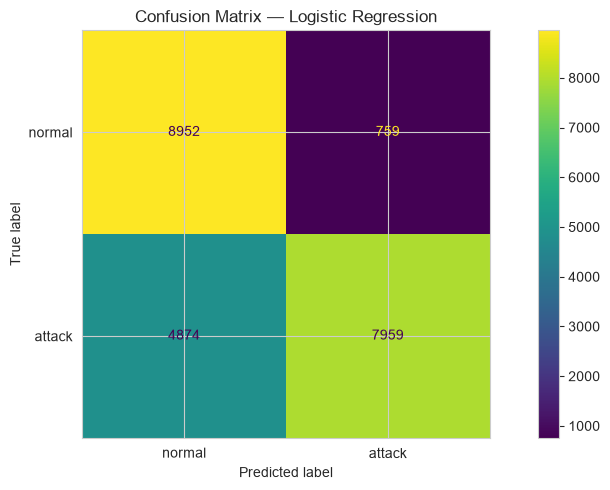


Training: Decision Tree
Best parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5}

Metrics:
Accuracy : 0.7571
Precision: 0.9639
Recall   : 0.5956
F1-score : 0.7362
CV F1    : 0.996

Classification report:
              precision    recall  f1-score   support

      normal       0.64      0.97      0.77      9711
      attack       0.96      0.60      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.80      0.78      0.76     22544
weighted avg       0.83      0.76      0.75     22544



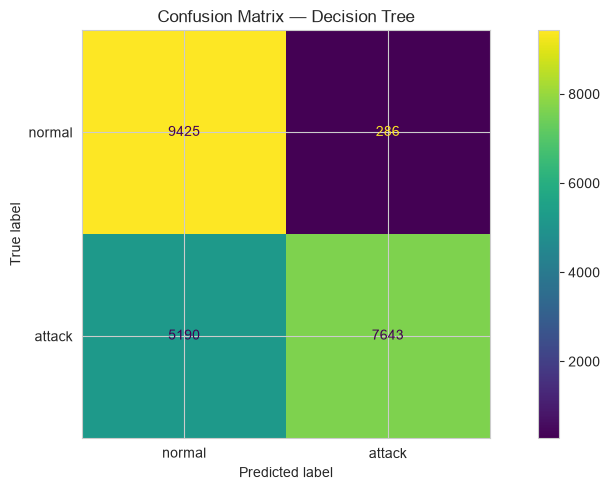


Training: Random Forest
Best parameters: {'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}

Metrics:
Accuracy : 0.7796
Precision: 0.9684
Recall   : 0.6334
F1-score : 0.7659
CV F1    : 0.9969

Classification report:
              precision    recall  f1-score   support

      normal       0.67      0.97      0.79      9711
      attack       0.97      0.63      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



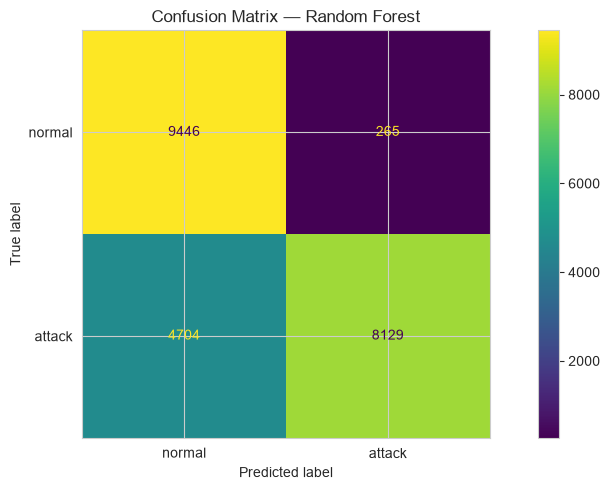


Training: Extra Trees
Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}

Metrics:
Accuracy : 0.7798
Precision: 0.9673
Recall   : 0.6346
F1-score : 0.7664
CV F1    : 0.9963

Classification report:
              precision    recall  f1-score   support

      normal       0.67      0.97      0.79      9711
      attack       0.97      0.63      0.77     12833

    accuracy                           0.78     22544
   macro avg       0.82      0.80      0.78     22544
weighted avg       0.84      0.78      0.78     22544



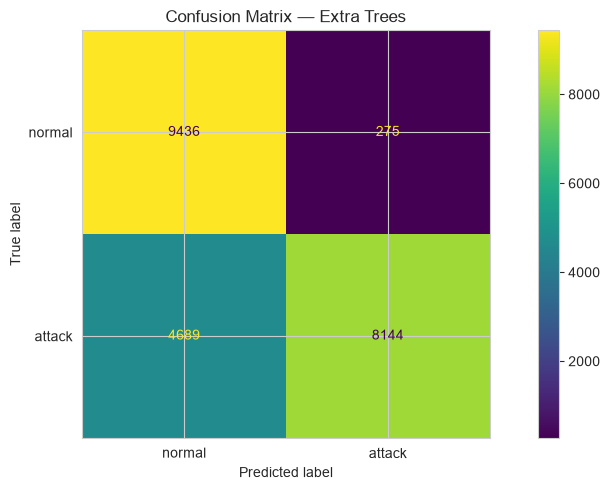


Training: KNN
Best parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}

Metrics:
Accuracy : 0.7631
Precision: 0.9675
Recall   : 0.6041
F1-score : 0.7438
CV F1    : 0.9921

Classification report:
              precision    recall  f1-score   support

      normal       0.65      0.97      0.78      9711
      attack       0.97      0.60      0.74     12833

    accuracy                           0.76     22544
   macro avg       0.81      0.79      0.76     22544
weighted avg       0.83      0.76      0.76     22544



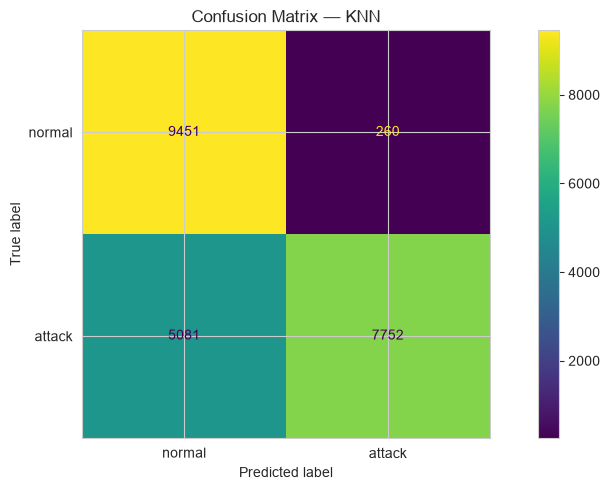


Training: MLP Neural Network
Best parameters: {'learning_rate_init': 0.005, 'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.0001}

Metrics:
Accuracy : 0.8043
Precision: 0.9455
Recall   : 0.6963
F1-score : 0.802
CV F1    : 0.9931

Classification report:
              precision    recall  f1-score   support

      normal       0.70      0.95      0.81      9711
      attack       0.95      0.70      0.80     12833

    accuracy                           0.80     22544
   macro avg       0.82      0.82      0.80     22544
weighted avg       0.84      0.80      0.80     22544



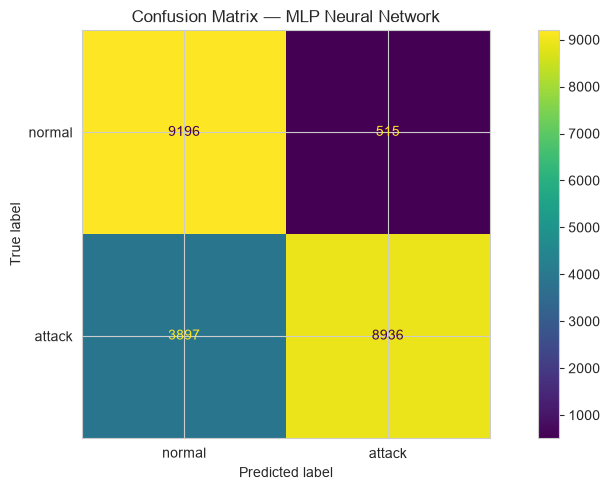

In [43]:
results = []
trained_models = {}
best_params = {}
roc_data = {}
pr_data = {}

for model_name, model in models.items():
    print("\n" + "=" * 90)
    print("Training:", model_name)
    print("=" * 90)
    
    start_train = time.time()
    
    # Heavy models use RandomizedSearchCV to reduce execution time
    if model_name in ["Random Forest", "Extra Trees", "MLP Neural Network"]:
        search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grids[model_name],
            n_iter=12,
            scoring="f1",
            cv=3,
            random_state=42,
            n_jobs=-1
        )
    else:
        search = GridSearchCV(
            estimator=model,
            param_grid=param_grids[model_name],
            scoring="f1",
            cv=3,
            n_jobs=-1
        )
    
    search.fit(X_train, y_train)
    
    training_time = time.time() - start_train
    
    best_model = search.best_estimator_
    trained_models[model_name] = best_model
    best_params[model_name] = search.best_params_
    
    print("Best parameters:", search.best_params_)
    
    # Prediction
    start_prediction = time.time()
    y_pred = best_model.predict(X_test)
    prediction_time = time.time() - start_prediction
    
    # Metrics
    metrics = evaluate_predictions(y_test, y_pred)
    
    # Cross-validation score on training data
    cv_scores = cross_val_score(
        best_model,
        X_train,
        y_train,
        cv=3,
        scoring="f1",
        n_jobs=-1
    )
    
    metrics["Model"] = model_name
    metrics["CV F1 mean"] = cv_scores.mean()
    metrics["CV F1 std"] = cv_scores.std()
    metrics["Training time"] = training_time
    metrics["Prediction time"] = prediction_time
    
    # ROC and Precision-Recall scores
    y_score = get_score(best_model, X_test)
    
    if y_score is not None:
        metrics["ROC AUC"] = roc_auc_score(y_test, y_score)
        metrics["Average Precision"] = average_precision_score(y_test, y_score)
        
        fpr, tpr, _ = roc_curve(y_test, y_score)
        precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_score)
        
        roc_data[model_name] = (fpr, tpr, metrics["ROC AUC"])
        pr_data[model_name] = (
            recall_curve,
            precision_curve,
            metrics["Average Precision"]
        )
    else:
        metrics["ROC AUC"] = np.nan
        metrics["Average Precision"] = np.nan
    
    results.append(metrics)
    
    # Display results
    print("\nMetrics:")
    print("Accuracy :", round(metrics["Accuracy"], 4))
    print("Precision:", round(metrics["Precision"], 4))
    print("Recall   :", round(metrics["Recall"], 4))
    print("F1-score :", round(metrics["F1-score"], 4))
    print("CV F1    :", round(metrics["CV F1 mean"], 4))
    
    print("\nClassification report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["normal", "attack"],
        zero_division=0
    ))
    
    plot_confusion(y_test, y_pred, f"Confusion Matrix — {model_name}")

## 6. Model comparison table

We collect the results from all models into one table.

The best model is the one with the highest F1-score.

In [44]:
comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="F1-score",
    ascending=False
).reset_index(drop=True)

comparison_df["Rank"] = comparison_df.index + 1

display(comparison_df[
    [
        "Rank",
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "CV F1 mean",
        "CV F1 std",
        "ROC AUC",
        "Average Precision",
        "Training time",
        "Prediction time"
    ]
])

,Rank,Model,Accuracy,Precision,Recall,F1-score,CV F1 mean,CV F1 std,ROC AUC,Average Precision,Training time,Prediction time
0,1,MLP Neural Network,0.804294,0.945508,0.696330,0.802010,0.993085,0.000485,0.929305,0.947801,187.682384,0.103504
1,2,Extra Trees,0.779808,0.967336,0.634614,0.766422,0.996288,0.000363,0.957972,0.962638,19.104023,0.077278
2,3,Random Forest,0.779587,0.968430,0.633445,0.765911,0.996886,0.000527,0.962332,0.967100,21.650503,0.130114
3,4,KNN,0.763086,0.967549,0.604068,0.743775,0.992113,0.000599,0.830582,0.848813,23.027048,3.206082
4,5,Logistic Regression,0.750133,0.912939,0.620198,0.738620,0.966472,0.002542,0.877080,0.907550,8.181477,0.005158
5,6,Decision Tree,0.757097,0.963930,0.595574,0.736249,0.995954,0.000575,0.835557,0.855302,24.707376,0.008013


## 7. Performance comparison plot

This bar chart compares Accuracy, Precision, Recall, and F1-score for all models.

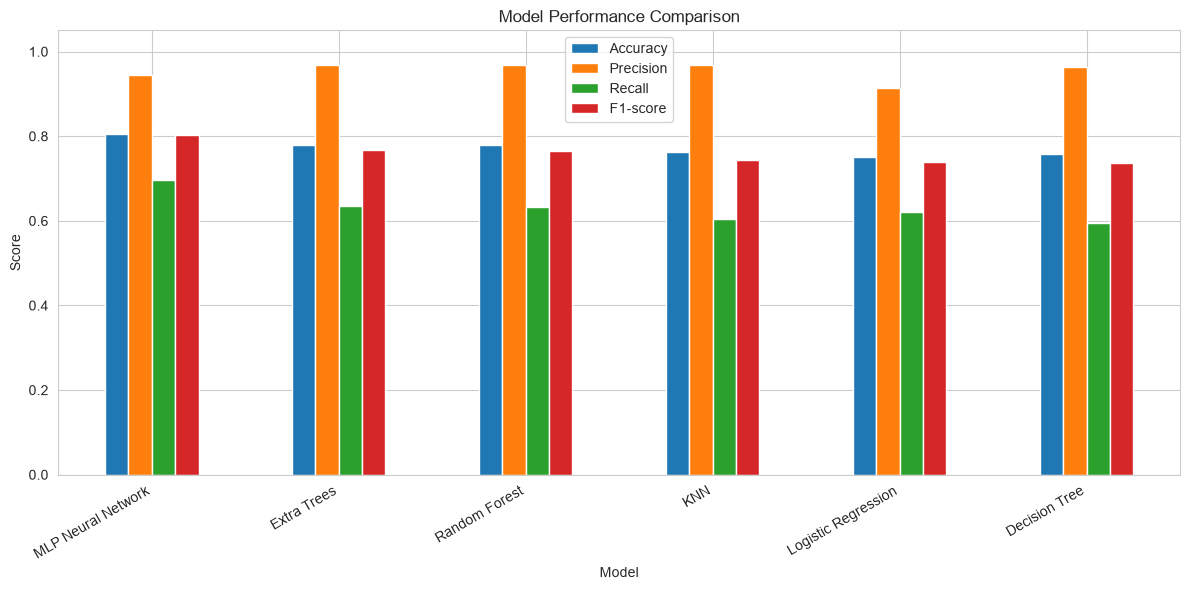

In [45]:
plot_df = comparison_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-score"]
]

plot_df.plot(kind="bar", figsize=(12, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 8. ROC curve comparison

The ROC curve compares the trade-off between the true positive rate and the false positive rate.

A higher AUC value means better discrimination between normal and attack traffic.

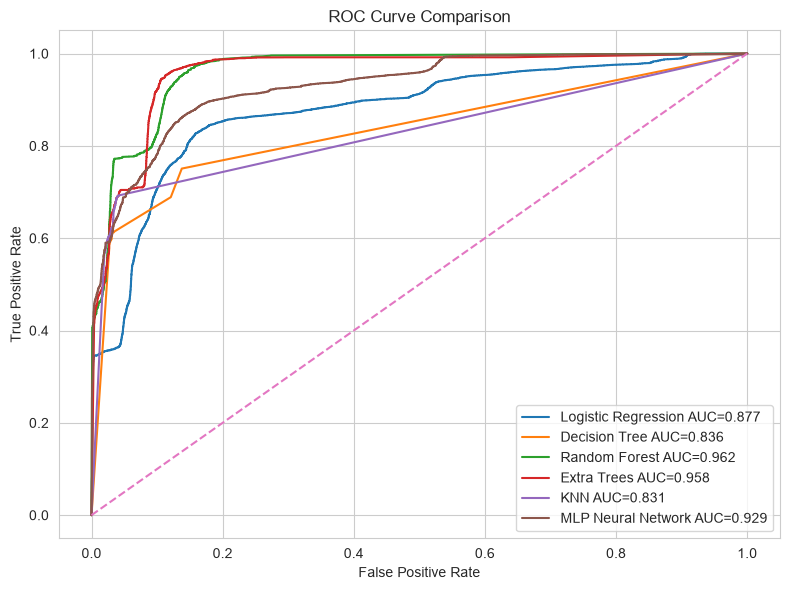

In [46]:
plt.figure(figsize=(8, 6))

for model_name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{model_name} AUC={auc_score:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Precision-Recall curve comparison

The Precision-Recall curve is especially useful for intrusion detection because the dataset can be imbalanced.

A higher Average Precision score means the model keeps high precision while detecting many attacks.

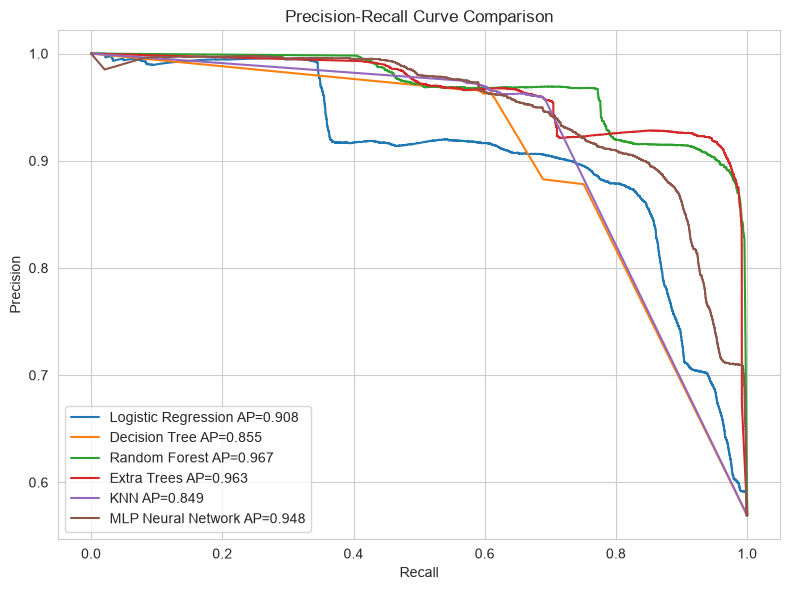

In [47]:
plt.figure(figsize=(8, 6))

for model_name, (recall_curve, precision_curve, ap_score) in pr_data.items():
    plt.plot(
        recall_curve,
        precision_curve,
        label=f"{model_name} AP={ap_score:.3f}"
    )

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Select the best model

We select the best model automatically using the F1-score.

F1-score is chosen because it balances:

- Precision: how many detected attacks are really attacks,
- Recall: how many real attacks are successfully detected.

Best model selected by F1-score: MLP Neural Network


,Accuracy,Precision,Recall,F1-score,Model,CV F1 mean,CV F1 std,Training time,Prediction time,ROC AUC,Average Precision,Rank
0,0.804294,0.945508,0.69633,0.80201,MLP Neural Network,0.993085,0.000485,187.682384,0.103504,0.929305,0.947801,1


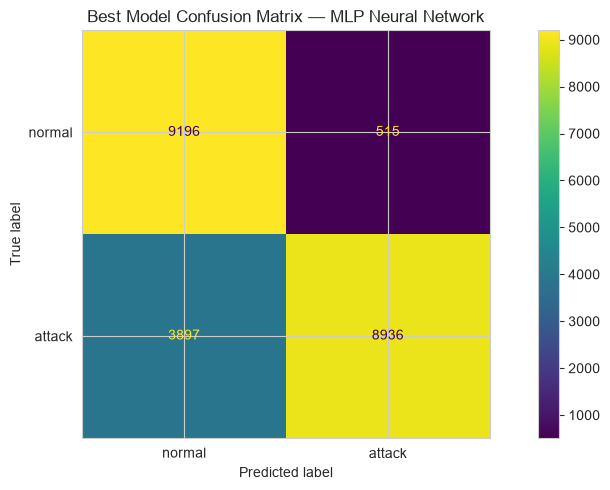

In [48]:
best_model_name = comparison_df.loc[0, "Model"]
best_model = trained_models[best_model_name]

print("Best model selected by F1-score:", best_model_name)

display(comparison_df.head(1))

best_pred = best_model.predict(X_test)

plot_confusion(
    y_test,
    best_pred,
    f"Best Model Confusion Matrix — {best_model_name}"
)

## 11. Feature importance

Tree-based models can provide feature importance.

This helps understand which network traffic features contributed most to the predictions.

,Feature,Importance
1,src_bytes,0.146318
2,dst_bytes,0.125315
39,flag_SF,0.076655
16,dst_host_same_srv_rate,0.057918
11,same_srv_rate,0.056225
12,diff_srv_rate,0.055461
15,dst_host_srv_count,0.047120
3,logged_in,0.042309
5,count,0.038674
17,dst_host_diff_srv_rate,0.034634


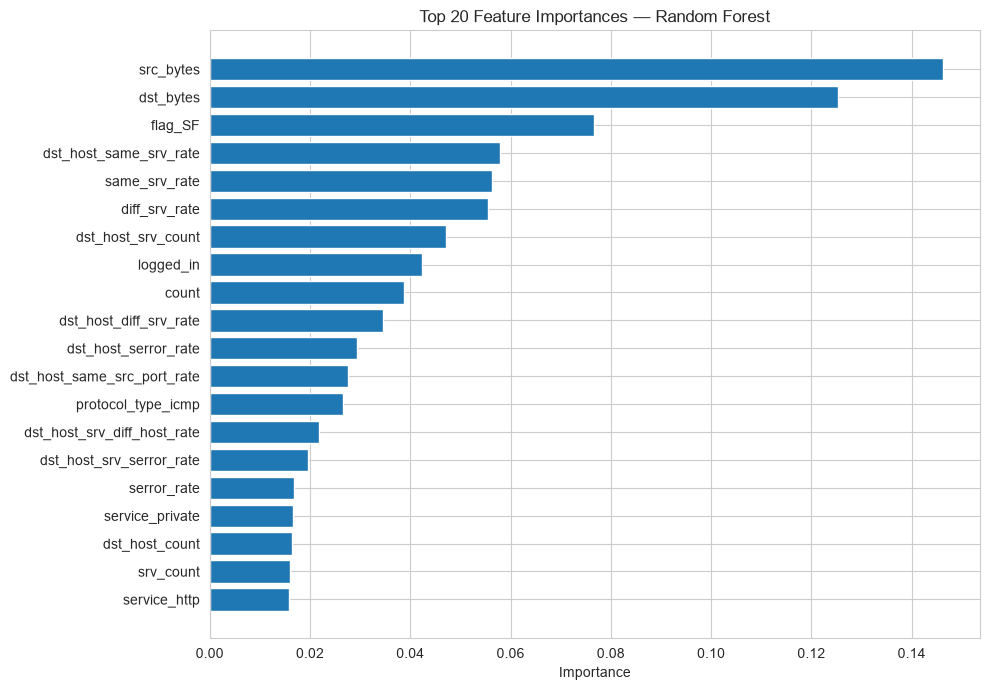

,Feature,Importance
39,flag_SF,0.103675
3,logged_in,0.087371
11,same_srv_rate,0.076327
16,dst_host_same_srv_rate,0.062729
15,dst_host_srv_count,0.049546
20,dst_host_serror_rate,0.047841
24,protocol_type_icmp,0.043471
38,flag_S0,0.041563
21,dst_host_srv_serror_rate,0.041155
7,serror_rate,0.041029


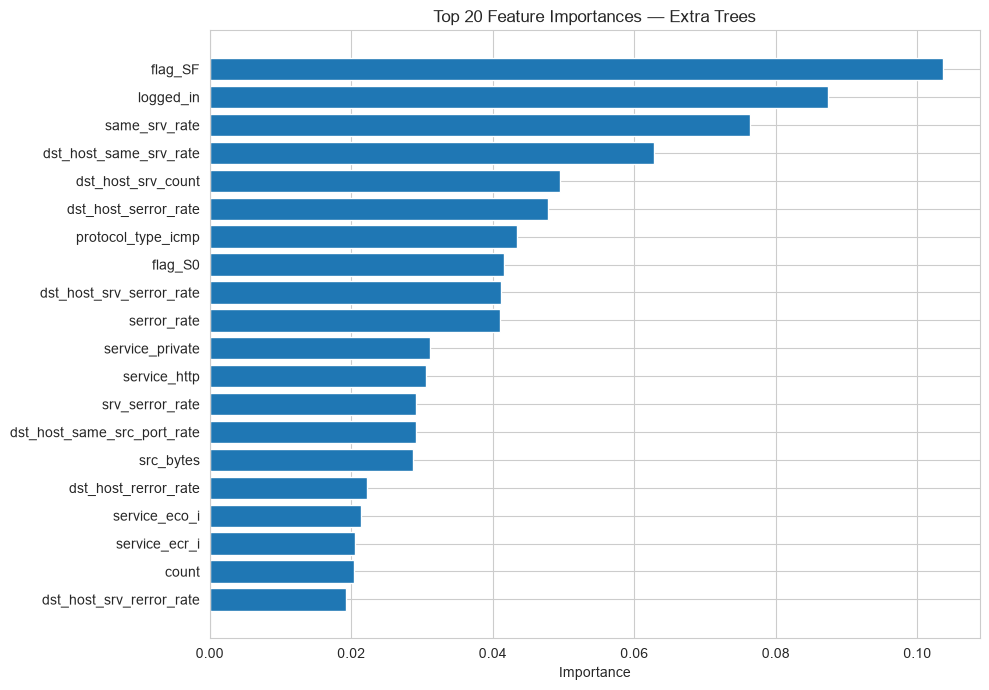

In [49]:
if "Random Forest" in trained_models:
    rf_importance = plot_feature_importance(
        trained_models["Random Forest"],
        "Random Forest"
    )
    
    rf_importance.to_csv(
        OUTPUT_DIR / "random_forest_feature_importance.csv",
        index=False
    )

if "Extra Trees" in trained_models:
    et_importance = plot_feature_importance(
        trained_models["Extra Trees"],
        "Extra Trees"
    )
    
    et_importance.to_csv(
        OUTPUT_DIR / "extra_trees_feature_importance.csv",
        index=False
    )

## 12. Neural Network loss curve

For the MLP Neural Network, we plot the loss curve.

The loss curve shows whether the neural network learned progressively during training.

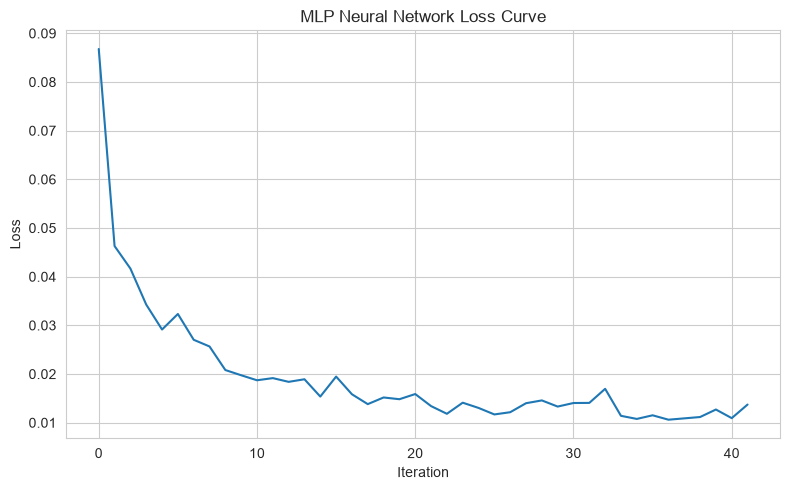

In [50]:
if "MLP Neural Network" in trained_models:
    mlp = trained_models["MLP Neural Network"]
    
    if hasattr(mlp, "loss_curve_"):
        plt.figure(figsize=(8, 5))
        plt.plot(mlp.loss_curve_)
        plt.title("MLP Neural Network Loss Curve")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.tight_layout()
        plt.show()

## 13. Save results

We save:

- the model ranking table,
- the best model,
- all trained models,
- the best hyperparameters.

This allows us to reuse the trained models without retraining everything.

In [51]:
comparison_df.to_csv(OUTPUT_DIR / "model_ranking.csv", index=False)

joblib.dump(best_model, OUTPUT_DIR / "best_model.pkl")
joblib.dump(trained_models, OUTPUT_DIR / "all_trained_models.pkl")
joblib.dump(best_params, OUTPUT_DIR / "best_params.pkl")

print("Saved files:")
print("-", OUTPUT_DIR / "model_ranking.csv")
print("-", OUTPUT_DIR / "best_model.pkl")
print("-", OUTPUT_DIR / "all_trained_models.pkl")
print("-", OUTPUT_DIR / "best_params.pkl")

Saved files:
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\model_ranking.csv
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\best_model.pkl
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\all_trained_models.pkl
- C:\Users\mbinmohdzaidi\Documents\ML_AIR_Attack\outputs\best_params.pkl


## 14. Final conclusion

The best model is selected according to the F1-score.

For intrusion detection, F1-score is more useful than accuracy because detecting attacks requires a good balance between:

- avoiding false alarms,
- detecting as many real attacks as possible.

The final ranking table shows which model performs best on the NSL-KDD test set.

In [52]:
print("FINAL CONCLUSION")
print("----------------")
print("Best model:", best_model_name)
print("Best F1-score:", round(comparison_df.loc[0, "F1-score"], 4))
print("Best accuracy:", round(comparison_df.loc[0, "Accuracy"], 4))
print("Best precision:", round(comparison_df.loc[0, "Precision"], 4))
print("Best recall:", round(comparison_df.loc[0, "Recall"], 4))

print("\nThe best model was selected using F1-score.")
print("This is appropriate because intrusion detection requires both high precision and high recall.")

FINAL CONCLUSION
----------------
Best model: MLP Neural Network
Best F1-score: 0.802
Best accuracy: 0.8043
Best precision: 0.9455
Best recall: 0.6963

The best model was selected using F1-score.
This is appropriate because intrusion detection requires both high precision and high recall.
